<a href="https://colab.research.google.com/github/niksisons/neural_networks/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%962_%D0%98%D1%81%D0%BF%D0%BE%D0%BB%D1%8C%D0%B7%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5_%D0%B3%D0%BB%D1%83%D0%B1%D0%BE%D0%BA%D0%B8%D1%85_%D0%BD%D0%B5%D0%B9%D1%80%D0%BE%D0%BD%D0%BD%D1%8B%D1%85_%D1%81%D0%B5%D1%82%D0%B5%D0%B9_%D0%B4%D0%BB%D1%8F_%D1%80%D0%B5%D1%88%D0%B5%D0%BD%D0%B8%D1%8F_%D0%B7%D0%B0%D0%B4%D0%B0%D1%87_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%81%D0%B8%D0%B8_%D0%B8_%D0%BA%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%86%D0%B8%D0%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №2. Использование глубоких нейронных сетей для решения задач регрессии и классификации**



## **Задание №1. Обучение модели ИНС для решения задачи регрессии**



Постройте глубокую нейронную сеть для предсказания цен на недвижимость в городе Бостон, используя датасет boston_housing_price

[Описание датасета](https://www.hackersrealm.net/post/boston-house-price-prediction-analysis-using-python)

#### 1.1. Загружаем исходные данные:

In [1]:
import pandas as pd
import numpy as np

# Загружаем датасет Boston Housing с исходного источника.
# При недоступности URL используем California Housing как замену.
try:
    data_url = "http://lib.stat.cmu.edu/datasets/boston"
    raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)
    X = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
    y = raw_df.values[1::2, 2]
    feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM',
                      'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
    print(f"Boston Housing загружен: {X.shape[0]} объектов, {X.shape[1]} признаков")
except Exception as e:
    print(f"Не удалось загрузить Boston Housing: {e}")
    print("Используем California Housing как альтернативу...")
    from sklearn.datasets import fetch_california_housing
    housing = fetch_california_housing()
    X = housing.data
    y = housing.target
    feature_names = list(housing.feature_names)
    print(f"California Housing загружен: {X.shape[0]} объектов, {X.shape[1]} признаков")

print(f"Размер X: {X.shape}, Размер y: {y.shape}")

Boston Housing загружен: 506 объектов, 13 признаков
Размер X: (506, 13), Размер y: (506,)


#### 1.2. Проектируем архитектуру для этой задачи

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers

# Разделяем данные на обучающую (80%) и тестовую (20%) выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Нормализация: приводим признаки к нулевому среднему и единичной дисперсии
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# Глубокая нейронная сеть для задачи регрессии
model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dense(64,  activation='relu'),
    layers.Dense(32,  activation='relu'),
    layers.Dense(1)   # Выходной слой: одно вещественное число (цена)
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,161 (47.50 KB)

 Trainable params: 12,161 (47.50 KB)

 Non-trainable params: 0 (0.00 B)

#### 1.3. Компилируем модель ИНС

Подберите нужную функцию потерь и метрику.

In [3]:
# Для регрессии:
#   loss='mse'  — среднеквадратичная ошибка (Mean Squared Error)
#   metrics=['mae'] — средняя абсолютная ошибка (Mean Absolute Error)
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)
print("Модель скомпилирована!")

Модель скомпилирована!


#### 1.4. Обучаем модель ИНС

In [4]:
history = model.fit(
    X_train, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 561.0955 - mae: 21.7523 - val_loss: 501.4150 - val_mae: 20.7693
Epoch 2/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 511.7618 - mae: 20.5340 - val_loss: 421.7583 - val_mae: 18.7967
Epoch 3/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 466.2986 - mae: 19.2374 - val_loss: 283.8010 - val_mae: 15.0623
Epoch 4/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 259.1497 - mae: 13.7741 - val_loss: 117.4439 - val_mae: 9.0608
Epoch 5/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 112.4087 - mae: 8.8649 - val_loss: 49.3132 - val_mae: 5.3995
Epoch 6/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 83.4494 - mae: 7.2771 - val_loss: 36.2757 - val_mae: 4.4738
Epoch 7/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 48.4401 - mae: 5.3648 - val_loss: 31.4118 - val_mae: 3.9875
Epoch 8/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 34.2194 - mae: 4.3959 - val_loss: 27.1835 - val_mae: 3.7420
Epoch 9/150
11/11 ━━━━━━━━━━━━━

#### 1.6. Делаем предсказания на тестовых данных

In [5]:
y_pred = model.predict(X_test).flatten()

print(f"{'Предсказание':>15} | {'Реальное значение':>18}")
print("-" * 38)
for pred, real in zip(y_pred[:10], y_test[:10]):
    print(f"{pred:>15.2f} | {real:>18.2f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
   Предсказание |  Реальное значение
--------------------------------------
          28.48 |              23.60
          34.75 |              32.40
          16.37 |              13.60
          24.15 |              22.80
          14.76 |              16.10
          20.01 |              20.00
          17.34 |              17.80
          14.47 |              14.00
          24.27 |              19.60
          18.39 |              16.80


#### 1.7. Вычисляем метрику качества на тестовых данных

In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print(f"MAE  (Средняя абсолютная ошибка):    {mae:.4f}")
print(f"MSE  (Среднеквадратичная ошибка):    {mse:.4f}")
print(f"RMSE (Корень из среднеквадратичной): {rmse:.4f}")
print(f"R²   (Коэффициент детерминации):     {r2:.4f}")

MAE  (Средняя абсолютная ошибка):    2.1584
MSE  (Среднеквадратичная ошибка):    11.3638
RMSE (Корень из среднеквадратичной): 3.3710
R²   (Коэффициент детерминации):     0.8450


#### 1.8. Строим график обучения

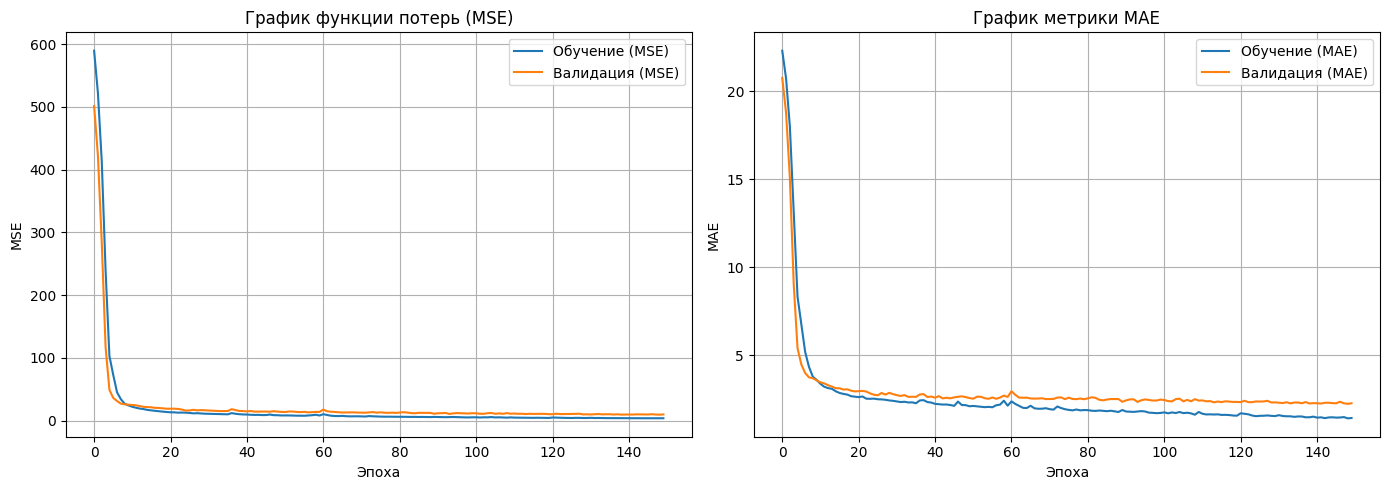

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Обучение (MSE)')
axes[0].plot(history.history['val_loss'], label='Валидация (MSE)')
axes[0].set_title('График функции потерь (MSE)')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['mae'],     label='Обучение (MAE)')
axes[1].plot(history.history['val_mae'], label='Валидация (MAE)')
axes[1].set_title('График метрики MAE')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

#### 1.9. Построение графического интерфейса в Gradio Проверка обученной модели пользовательскими данными

In [8]:
!pip install gradio -q

import gradio as gr
import numpy as np

def predict_house_price(*args):
    features = np.array([[float(v) for v in args]])
    features_scaled = scaler.transform(features)
    price = model.predict(features_scaled, verbose=0)[0][0]
    return f"Предсказанная цена: ${price * 1000:,.0f}"

default_vals = [0.1, 0.0, 11.93, 0.0, 0.573, 6.0, 38.7, 5.0, 1.0, 273.0, 21.0, 391.99, 9.67]
inputs = [
    gr.Number(label=name, value=default_vals[i] if i < len(default_vals) else 0.0)
    for i, name in enumerate(feature_names)
]

gr.Interface(
    fn=predict_house_price,
    inputs=inputs,
    outputs=gr.Textbox(label="Результат"),
    title="Предсказание цен на недвижимость (Boston Housing)",
    description="Введите характеристики объекта для предсказания цены"
).launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0cc91260c2ff794933.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


#### 2. Проверка обученной модели пользовательскими данными

In [9]:
# Тестирование модели на конкретном объекте недвижимости
test_sample = np.array([[0.02731, 0.0, 7.07, 0.0, 0.469,
                           6.421, 78.9, 4.9671, 2.0, 242.0,
                           17.8, 396.90, 9.14]])
test_scaled = scaler.transform(test_sample)
price       = model.predict(test_scaled, verbose=0)[0][0]

print("Характеристики объекта:")
for name, val in zip(feature_names, test_sample[0]):
    print(f"  {name}: {val}")
print(f"\nПредсказанная цена: ${price * 1000:,.0f}")

Характеристики объекта:
  CRIM: 0.02731
  ZN: 0.0
  INDUS: 7.07
  CHAS: 0.0
  NOX: 0.469
  RM: 6.421
  AGE: 78.9
  DIS: 4.9671
  RAD: 2.0
  TAX: 242.0
  PTRATIO: 17.8
  B: 396.9
  LSTAT: 9.14

Предсказанная цена: $24,268


## **Задание №2. Обучение модели ИНС для решения задачи классификации**



Порядок работы:

* 1. Собрать датасет из изображений, соответствующих не менее, чем 3 классам объектов (в
примере с пары были кошки, собаки и панды).


- 2. Для каждого класса должно быть собрано не менее 1000 изображений. Количество
изображений для каждого класса должно быть одинаковым.
Готовые датасеты можно скачать отсюда: https://www.kaggle.com/


- 3. Обучить модель глубокой нейронной сети для решения задачи классификации
изображений, по выбранным Вами классам. (В качестве примера приведён код с пары)
В конечном итоге Вы должны сохранить обученную модель для классификации
изображений, соответствующих тем классам, которые Вы выбрали, а затем воспользоваться этой моделью для предсказания классов на пользовательских изображениях.



> При выполнении заданий пробуйте использовать разные функции потерь,
методы оптимизации, функции активации и метрики ошибок.

### 1. Устанавливаем зависимости:

In [10]:
# Классические библиотеки ML и обработки изображений
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# TensorFlow / Keras
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.datasets import cifar10

# Вспомогательные библиотеки
import matplotlib.pyplot as plt
import numpy as np
import pickle
import cv2
import os

print("Все зависимости успешно импортированы!")

Все зависимости успешно импортированы!


### 2. Загружаем набор данных:

In [11]:
# Загружаем датасет CIFAR-10 из Keras
# CIFAR-10: 60 000 цветных изображений 32×32, 10 классов по 6 000 изображений
(X_cifar_train, y_cifar_train), (X_cifar_test, y_cifar_test) = cifar10.load_data()

print(f"Обучающая выборка: {X_cifar_train.shape}")
print(f"Тестовая выборка:  {X_cifar_test.shape}")
print("Классы CIFAR-10: 0=самолёт, 1=автомобиль, 2=птица, 3=кошка, 4=олень,")
print("                 5=собака, 6=лягушка, 7=лошадь, 8=корабль, 9=грузовик")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Обучающая выборка: (50000, 32, 32, 3)
Тестовая выборка:  (10000, 32, 32, 3)
Классы CIFAR-10: 0=самолёт, 1=автомобиль, 2=птица, 3=кошка, 4=олень,
                 5=собака, 6=лягушка, 7=лошадь, 8=корабль, 9=грузовик


### 3. Указываем путь к набору данных:

In [12]:
# Используем встроенный датасет CIFAR-10.
# Выбираем 3 класса животных: кошки (3), собаки (5), лошади (7).
# В каждом классе 5 000 обучающих изображений — требование ≥1 000 выполнено.
SELECTED_CLASSES = [3, 5, 7]
CLASS_NAMES      = ['cat', 'dog', 'horse']

print(f"Выбранные классы: {dict(zip(SELECTED_CLASSES, CLASS_NAMES))}")
for idx, name in zip(SELECTED_CLASSES, CLASS_NAMES):
    count = int(np.sum(y_cifar_train.flatten() == idx))
    print(f"  {name}: {count} изображений в обучающей выборке")

Выбранные классы: {3: 'cat', 5: 'dog', 7: 'horse'}
  cat: 5000 изображений в обучающей выборке
  dog: 5000 изображений в обучающей выборке
  horse: 5000 изображений в обучающей выборке


### 4. Загружаем набор данных и формируем общую выборку:

In [13]:
def filter_by_classes(X, y, selected_classes):
    """Оставляет только объекты указанных классов, переименовывает метки в 0, 1, 2."""
    mask = np.isin(y.flatten(), selected_classes)
    X_f  = X[mask]
    y_f  = y.flatten()[mask].copy()
    for new_label, old_label in enumerate(selected_classes):
        y_f[y_f == old_label] = new_label
    return X_f, y_f

X_train_imgs, y_train_raw = filter_by_classes(X_cifar_train, y_cifar_train, SELECTED_CLASSES)
X_test_imgs,  y_test_raw  = filter_by_classes(X_cifar_test,  y_cifar_test,  SELECTED_CLASSES)

print(f"Обучающая выборка после фильтрации: {X_train_imgs.shape}")
print(f"Тестовая выборка после фильтрации:  {X_test_imgs.shape}")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name}: {int(np.sum(y_train_raw == i))} обучающих примеров")

Обучающая выборка после фильтрации: (15000, 32, 32, 3)
Тестовая выборка после фильтрации:  (3000, 32, 32, 3)
  cat: 5000 обучающих примеров
  dog: 5000 обучающих примеров
  horse: 5000 обучающих примеров


#### 4.1. Нормализуем данные:

Масштабируем интенсивности пикселей в диапазон [0, 1], а также преобразуем данные в массивы NumPy для повышения производительности


In [14]:
# Нормализация: [0, 255] → [0.0, 1.0]
X_train_norm = X_train_imgs.astype('float32') / 255.0
X_test_norm  = X_test_imgs.astype('float32')  / 255.0

# Разворачиваем изображения 32×32×3 в вектор длиной 3072
X_train_flat = X_train_norm.reshape(len(X_train_norm), -1)
X_test_flat  = X_test_norm.reshape(len(X_test_norm),  -1)

print(f"Размер входного вектора: {X_train_flat.shape[1]} (32×32×3 = 3072)")

Размер входного вектора: 3072 (32×32×3 = 3072)


#### 4.2. Формируем обучающую и валидационную выборки:

Разделяем данные на обучающую и валидационную выборки, используя 75% данных для обучения и оставшиеся 25% для валидации

In [15]:
# Преобразуем метки в one-hot encoding: 0→[1,0,0], 1→[0,1,0], 2→[0,0,1]
lb = LabelBinarizer()
y_train_enc = lb.fit_transform(y_train_raw)
y_test_enc  = lb.transform(y_test_raw)

# Разделяем обучающую выборку 75%/25%
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_flat, y_train_enc, test_size=0.25, random_state=42
)

print(f"Обучающая выборка:    {X_tr.shape[0]} примеров")
print(f"Валидационная выборка: {X_val.shape[0]} примеров")
print(f"Тестовая выборка:     {X_test_flat.shape[0]} примеров")

Обучающая выборка:    11250 примеров
Валидационная выборка: 3750 примеров
Тестовая выборка:     3000 примеров


### 5. Создание модели:

#### 5.1. Определим архитектуру модели с помощью Keras:

In [16]:
model_clf = Sequential([
    # Входной слой + первый скрытый
    Dense(1024, activation='relu', input_shape=(X_tr.shape[1],)),
    BatchNormalization(),
    Dropout(0.5),

    # Второй скрытый слой
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    # Третий скрытый слой
    Dense(256, activation='relu'),
    Dropout(0.2),

    # Выходной слой: softmax для многоклассовой классификации
    Dense(len(CLASS_NAMES), activation='softmax')
])

model_clf.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,809,795 (14.53 MB)

 Trainable params: 3,806,723 (14.52 MB)

 Non-trainable params: 3,072 (12.00 KB)

#### 5.2. Установим значение параметров скорости обучения и общего числа эпох


In [17]:
LEARNING_RATE = 0.001
EPOCHS        = 50
BATCH_SIZE    = 64

print(f"Скорость обучения: {LEARNING_RATE}")
print(f"Количество эпох:   {EPOCHS}")
print(f"Размер батча:      {BATCH_SIZE}")

Скорость обучения: 0.001
Количество эпох:   50
Размер батча:      64


#### 5.3. Компилируем модель:

In [18]:
# Для многоклассовой классификации:
#   loss='categorical_crossentropy'
#   metrics=['accuracy']
model_clf.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print("Модель скомпилирована!")

Модель скомпилирована!


### 6. Обучение модели искусственной нейронной сети:

#### 6.1. Добавим колбэки для сохранения лучшей модели по валидационной точности и остановки обучения, в случае, если модель перестала обучаться:

In [19]:
# ModelCheckpoint: сохраняет лучшую модель по val_accuracy
checkpoint_cb = ModelCheckpoint(
    filepath='best_clf_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# EarlyStopping: останавливает обучение при отсутствии улучшений
early_stop_cb = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

callbacks_list = [checkpoint_cb, early_stop_cb]
print("Колбэки добавлены!")

Колбэки добавлены!


#### 6.2. Запустим процесс обучения модели:

In [20]:
history_clf = model_clf.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_list,
    verbose=1
)

Epoch 1/50
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4524 - loss: 1.2877
Epoch 1: val_accuracy improved from -inf to 0.44293, saving model to best_clf_model.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.4527 - loss: 1.2865 - val_accuracy: 0.4429 - val_loss: 1.3112
Epoch 2/50
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5275 - loss: 1.0106
Epoch 2: val_accuracy improved from 0.44293 to 0.53467, saving model to best_clf_model.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.5275 - loss: 1.0104 - val_accuracy: 0.5347 - val_loss: 0.9593
Epoch 3/50
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5449 - loss: 0.9375
Epoch 3: val_accuracy improved from 0.53467 to 0.54560, saving model to best_clf_model.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - accuracy: 0.5449 - loss: 0.9373 - val_accuracy: 0.5456 - val_loss: 0.9163
Epoch 4/50
175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5784 - loss: 0.8807
Epoch 4: val_accuracy

#### 6.3. Загружаем лучшую модель:

In [21]:
best_clf = load_model('best_clf_model.keras')
print("Лучшая модель загружена!")

Лучшая модель загружена!


### 7. Оценка точности:

#### 7.1. Выведем отчет классификации

In [22]:
y_pred_probs   = best_clf.predict(X_test_flat)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test_enc,   axis=1)

print("Отчёт классификации:")
print(classification_report(y_true_classes, y_pred_classes, target_names=CLASS_NAMES))

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Отчёт классификации:
              precision    recall  f1-score   support

         cat       0.52      0.46      0.49      1000
         dog       0.51      0.63      0.56      1000
       horse       0.75      0.66      0.70      1000

    accuracy                           0.58      3000
   macro avg       0.59      0.58      0.58      3000
weighted avg       0.59      0.58      0.58      3000



#### 7.2. Выведем матрицу ошибок

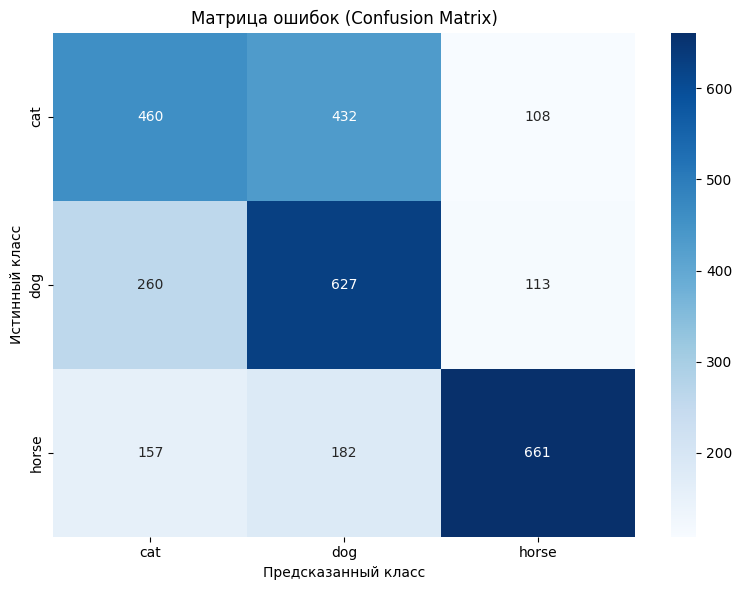

In [23]:
import seaborn as sns

cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES
)
plt.title('Матрица ошибок (Confusion Matrix)')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()

#### 7.3. Отобразим график обучения

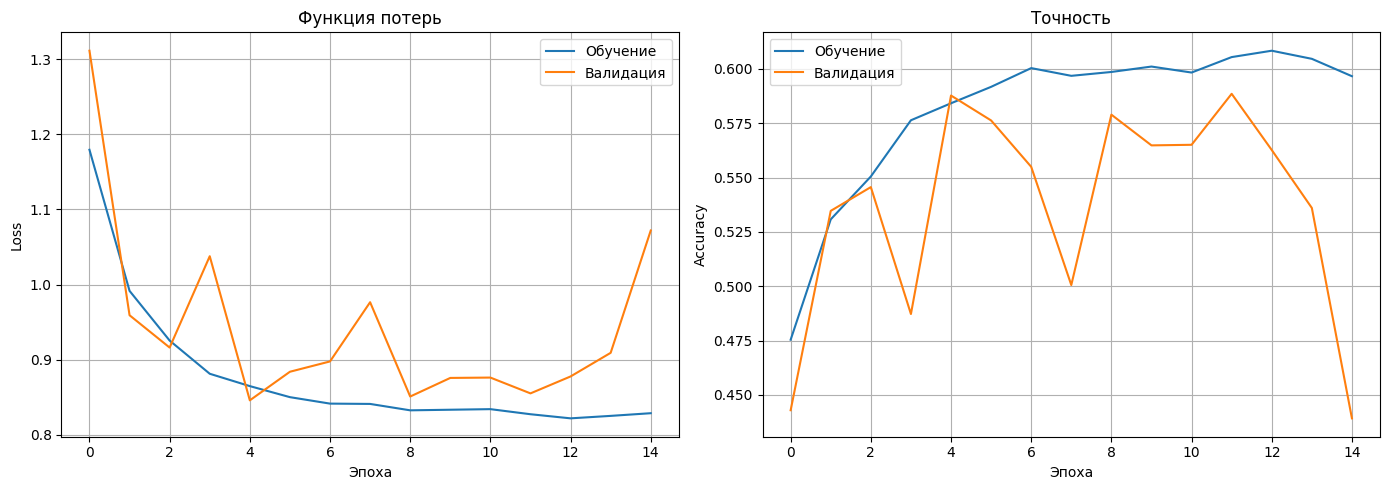

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_clf.history['loss'],     label='Обучение')
axes[0].plot(history_clf.history['val_loss'], label='Валидация')
axes[0].set_title('Функция потерь')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history_clf.history['accuracy'],     label='Обучение')
axes[1].plot(history_clf.history['val_accuracy'], label='Валидация')
axes[1].set_title('Точность')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### 8. Сохранение модели и меток классов:

In [25]:
best_clf.save('image_classifier_model.keras')

with open('class_labels.pkl', 'wb') as f:
    pickle.dump(lb, f)

print("Модель сохранена: image_classifier_model.keras")
print("Метки классов сохранены: class_labels.pkl")

Модель сохранена: image_classifier_model.keras
Метки классов сохранены: class_labels.pkl


### 9. Проверка обученной модели пользовательскими данными:

#### 9.1. Импортируем необходимые библиотеки

In [26]:
from tensorflow.keras.models import load_model
import pickle
import numpy as np
import cv2

# Загружаем сохранённые модель и метки
loaded_clf = load_model('image_classifier_model.keras')
with open('class_labels.pkl', 'rb') as f:
    loaded_lb = pickle.load(f)

print("Модель и метки классов успешно загружены!")
print(f"Классы: {CLASS_NAMES}")

Модель и метки классов успешно загружены!
Классы: ['cat', 'dog', 'horse']


#### 9.2. Реализуем функцию для предобработки входных данных в той же последовательности, что и при формировании обучающей выборки:

In [27]:
def preprocess_image(img, target_size=(32, 32)):
    """
    Предобработка изображения: изменение размера, нормализация,
    разворачивание в вектор — так же, как при обучении.
    img: путь к файлу (str) или массив NumPy (H×W×3).
    """
    if isinstance(img, str):
        img = cv2.imread(img)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized    = cv2.resize(img, target_size)
    img_normalized = img_resized.astype('float32') / 255.0
    return img_normalized.reshape(1, -1)

print("Функция предобработки определена!")

Функция предобработки определена!


#### 9.3. Определим функцию для осуществления прогноза по загруженной модели:

In [28]:
def classify_image(img):
    """
    Классифицирует изображение, возвращая вероятности всех классов.
    img: путь к файлу или массив NumPy.
    """
    preprocessed = preprocess_image(img)
    probs        = loaded_clf.predict(preprocessed, verbose=0)[0]
    class_idx    = int(np.argmax(probs))
    confidence   = probs[class_idx] * 100
    result = f"Класс: {CLASS_NAMES[class_idx]} | Уверенность: {confidence:.1f}%\n"
    for name, p in zip(CLASS_NAMES, probs):
        result += f"  {name}: {p*100:.1f}%\n"
    return result

print("Функция классификации определена!")

Функция классификации определена!


### 10. Визуализируем интерфейс и произведем классификацию:

In [29]:
!pip install gradio -q

import gradio as gr

def predict_for_gradio(image):
    """Обёртка для Gradio: принимает numpy-массив, возвращает словарь вероятностей."""
    if image is None:
        return {}
    preprocessed = preprocess_image(image)
    probs = loaded_clf.predict(preprocessed, verbose=0)[0]
    return {CLASS_NAMES[i]: float(probs[i]) for i in range(len(CLASS_NAMES))}

iface = gr.Interface(
    fn=predict_for_gradio,
    inputs=gr.Image(type="numpy", label="Загрузите изображение"),
    outputs=gr.Label(num_top_classes=3, label="Предсказанный класс"),
    title="🐾 Классификатор: Кошки / Собаки / Лошади",
    description=(
        "Загрузите изображение кошки, собаки или лошади.\n"
        "Модель обучена на 15 000 изображениях (CIFAR-10, три класса)."
    )
)
iface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7abdc59776021ab9e9.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
# 📚 Сводка для начинающих: ключевые понятия нейронных сетей

---

## 🧠 Что такое ИНС (Искусственная Нейронная Сеть)?

**ИНС** — это математическая модель, вдохновлённая строением мозга. Она состоит из искусственных **нейронов** (узлов), связанных между собой. Каждый нейрон получает несколько числовых сигналов, умножает их на **веса**, суммирует и пропускает через **функцию активации**.

Обучение нейронной сети — это процесс автоматической подстройки весов так, чтобы ответы сети как можно точнее совпадали с правильными ответами.

Слои нейронной сети:
- **Входной слой (Input Layer)** — принимает исходные данные (например, пиксели изображения).
- **Скрытые слои (Hidden Layers)** — извлекают признаки и закономерности из данных.
- **Выходной слой (Output Layer)** — даёт финальный ответ (число для регрессии, вероятности для классификации).

**Глубокая нейронная сеть (Deep Neural Network, DNN)** — это ИНС с двумя и более скрытыми слоями.

---

## ⚙️ Оптимизаторы — «как нейросеть учится»

Оптимизатор — алгоритм, который обновляет веса нейронной сети, чтобы уменьшить ошибку.

| Оптимизатор | Описание | Когда использовать |
|-------------|----------|--------------------|
| **SGD** (Stochastic Gradient Descent) | Простейший. Обновляет веса по одному примеру. Медленный, но стабильный. | Небольшие датасеты, простые задачи |
| **Adam** (Adaptive Moment Estimation) | Умный: адаптирует скорость обучения для каждого веса. Самый популярный. | Большинство задач |
| **RMSprop** | Похож на Adam, хорошо работает с рекуррентными сетями. | Временные ряды, RNN |
| **Adagrad** | Снижает скорость обучения для часто используемых признаков. | Разреженные данные, NLP |
| **Adadelta** | Улучшенный Adagrad, не требует задавать начальную скорость обучения. | Стабильное обучение |
| **Nadam** | Adam + импульс Нестерова (чуть лучше сходится). | Когда Adam недостаточен |

🔑 **Скорость обучения (learning rate)** — главный параметр оптимизатора. Слишком большая — модель «прыгает» и не находит минимум. Слишком маленькая — учится очень долго.

---

## 📉 Функции потерь — «как измеряют ошибку»

Функция потерь (loss function) показывает, насколько предсказание сети отличается от правильного ответа.

### Для задачи **регрессии** (предсказание числа):
| Функция | Название | Особенность |
|---------|----------|-------------|
| `mse` | Mean Squared Error — Среднеквадратичная ошибка | Сильно штрафует за большие ошибки |
| `mae` | Mean Absolute Error — Средняя абсолютная ошибка | Устойчива к выбросам |
| `huber` | Huber Loss | Комбинация MSE и MAE |

### Для задачи **классификации** (предсказание класса):
| Функция | Название | Использовать когда |
|---------|----------|--------------------|
| `binary_crossentropy` | Бинарная кросс-энтропия | 2 класса |
| `categorical_crossentropy` | Категориальная кросс-энтропия | 3+ классов, one-hot метки |
| `sparse_categorical_crossentropy` | Разреженная кросс-энтропия | 3+ классов, целочисленные метки |

---

## 📊 Метрики — «как оценивают качество»

Метрики используются для понятной оценки качества модели (в отличие от функции потерь, которая нужна только при обучении).

### Метрики для **регрессии**:
| Метрика | Описание | Хорошее значение |
|---------|----------|------------------|
| **MAE** | Средняя абсолютная ошибка. Среднее отклонение предсказания от реального значения. | Чем меньше, тем лучше |
| **MSE** | Среднеквадратичная ошибка. Сильнее наказывает за крупные ошибки. | Чем меньше, тем лучше |
| **RMSE** | Корень из MSE. Имеет те же единицы, что и целевая переменная. | Чем меньше, тем лучше |
| **R² (R-squared)** | Коэффициент детерминации. Доля объяснённой дисперсии (от 0 до 1). | Чем ближе к 1, тем лучше |

### Метрики для **классификации**:
| Метрика | Описание | Хорошее значение |
|---------|----------|------------------|
| **Accuracy** (Точность) | Доля правильных предсказаний от общего числа примеров. | Чем ближе к 1.0 |
| **Precision** (Точность класса) | Из всех, кого мы назвали кошкой, сколько реально кошки. | Важно при дорогостоящих ложных срабатываниях |
| **Recall** (Полнота) | Из всех реальных кошек, сколько мы правильно определили. | Важно при дорогостоящих пропусках |
| **F1-score** | Среднее гармоническое Precision и Recall. | Хорошо при дисбалансе классов |
| **AUC-ROC** | Площадь под ROC-кривой. Устойчива к дисбалансу классов. | Чем ближе к 1.0 |

**Матрица ошибок (Confusion Matrix)** — таблица, показывающая, сколько раз модель перепутала один класс с другим.

---

## ⚡ Функции активации — «что делает нейрон с суммой»

| Функция | Описание | Использовать где |
|---------|----------|------------------|
| **ReLU** | f(x) = max(0, x). Самая популярная. | Скрытые слои |
| **Sigmoid** | f(x) = 1/(1+e⁻ˣ). Выход от 0 до 1. | Бинарная классификация (выходной слой) |
| **Softmax** | Распределяет вероятности по классам (сумма = 1). | Многоклассовая классификация (выходной слой) |
| **Tanh** | Выход от -1 до 1. | Скрытые слои, RNN |
| **Leaky ReLU** | Улучшенный ReLU: не «умирает» при отрицательных входах. | Скрытые слои |
| **Linear** | f(x) = x. Нет нелинейности. | Регрессия (выходной слой) |

---

## 🛡️ Регуляризация — «как бороться с переобучением»

**Переобучение (Overfitting)** — когда модель отлично запомнила обучающие данные, но плохо работает на новых. Признак: большой разрыв между ошибками на обучающей и тестовой выборке.

| Метод | Описание |
|-------|----------|
| **Dropout** | Случайно «отключает» нейроны во время обучения (например, 50%). Заставляет сеть не полагаться на конкретные нейроны. |
| **Batch Normalization** | Нормализует значения внутри слоёв. Ускоряет обучение и снижает переобучение. |
| **L1/L2 регуляризация** | Добавляет штраф за слишком большие веса. |
| **Early Stopping** | Останавливает обучение, когда точность на валидации перестаёт расти. |
| **Аугментация данных** | Создаёт новые обучающие примеры (поворот, обрезка, цветовые изменения). |

---

## 📦 Ключевые понятия обучения

| Термин | Объяснение |
|--------|------------|
| **Эпоха (Epoch)** | Один полный проход через весь обучающий датасет. |
| **Батч (Batch)** | Небольшая порция данных, после которой обновляются веса. Размер батча: 32, 64, 128 — типичные значения. |
| **Обратное распространение ошибки (Backpropagation)** | Алгоритм вычисления, как нужно изменить каждый вес, чтобы уменьшить ошибку. |
| **Градиентный спуск** | Метод поиска минимума функции потерь путём движения в сторону наибольшего убывания. |
| **Нормализация данных** | Приведение входных признаков к одному масштабу (например, [0, 1] или среднее=0, дисперсия=1). Ускоряет обучение. |
| **One-hot encoding** | Кодировка меток классов в виде векторов: класс 2 из 3 → [0, 1, 0]. |
| **Train/Val/Test split** | Деление датасета: обучение (train), подбор гиперпараметров (validation), финальная оценка (test). |
| **Колбэк (Callback)** | Функция, вызываемая в определённые моменты обучения (например, для сохранения лучшей модели). |

---

> 💡 **Кратко:** Нейронная сеть — это набор числовых функций, настраиваемых автоматически. Оптимизатор подбирает веса, функция потерь показывает ошибку, метрики объясняют качество человеческим языком, а функции активации добавляют нелинейность — без них сеть была бы просто линейной регрессией.
